In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
from datetime import datetime 
torch.manual_seed(123)
import torchvision
from torchvision.ops import box_convert, complete_box_iou_loss
import math
from torch.utils.data import TensorDataset, DataLoader


### Load data and preprocessing

In [76]:
def normalize(train, val, test):
    train_tensors = train.tensors[0]  # Get the underlying tensor
    val_tensors = val.tensors[0]  
    test_tensors = test.tensors[0]  

    mean = train_tensors.mean()    # Mean per feature
    std  = train_tensors.std()     # Std per feature
    
    train_norm = (train_tensors - mean) / std 
    val_norm = (val_tensors - mean) / std 
    test_norm = (test_tensors - mean) / std 
    return TensorDataset(train_norm, train.tensors[1]), TensorDataset(val_norm, val.tensors[1]), TensorDataset(test_norm, test.tensors[1])


In [77]:
# TODO
# Load the data
def load_data():
    train = torch.load('data/localization_train.pt', weights_only=False)
    val = torch.load('data/localization_val.pt', weights_only=False)
    test = torch.load('data/localization_test.pt', weights_only=False)
    norm_train, norm_val, norm_test = normalize(train, val, test)
    return train, val, test, norm_train, norm_val, norm_test

train, val, test, norm_train, norm_val, norm_test = load_data()
print(f'Train size: {len(train)}')
print(f'Val size: {len(val)}')
print(f'Test size: {len(test)}')  


labels = train.tensors[1]
# første indeks i label
class_ids = labels[:, 0]
digits = labels[:, -1].long()  # convert to integer

total = len(labels)
no_object = (class_ids == 0).sum().item()
has_object = (class_ids != 0).sum().item()

digit_counts = torch.bincount(digits, minlength=10)
for i in range(10):
    percentage = (digit_counts[i].item() / total) * 100 if total > 0 else 0
    print(f"Digit: {i}: {percentage:.2f}%")

print(f"Color-range: {int(train.tensors[0].min().item())} to {int(train.tensors[0].max().item())}")
print(f"Total samples: {total}")
print(f"No object: {no_object}")
print(f"Has object: {has_object}")
print(f"Image shape: {train.tensors[0].shape[1:]}")
print("Label:", train.tensors[1][0])





Train size: 59400
Val size: 6600
Test size: 11000
Digit: 0: 9.00%
Digit: 1: 19.32%
Digit: 2: 9.03%
Digit: 3: 9.30%
Digit: 4: 8.83%
Digit: 5: 8.23%
Digit: 6: 8.94%
Digit: 7: 9.50%
Digit: 8: 8.84%
Digit: 9: 9.02%
Color-range: 0 to 1
Total samples: 59400
No object: 5400
Has object: 54000
Image shape: torch.Size([1, 48, 60])
Label: tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167, 4.0000])


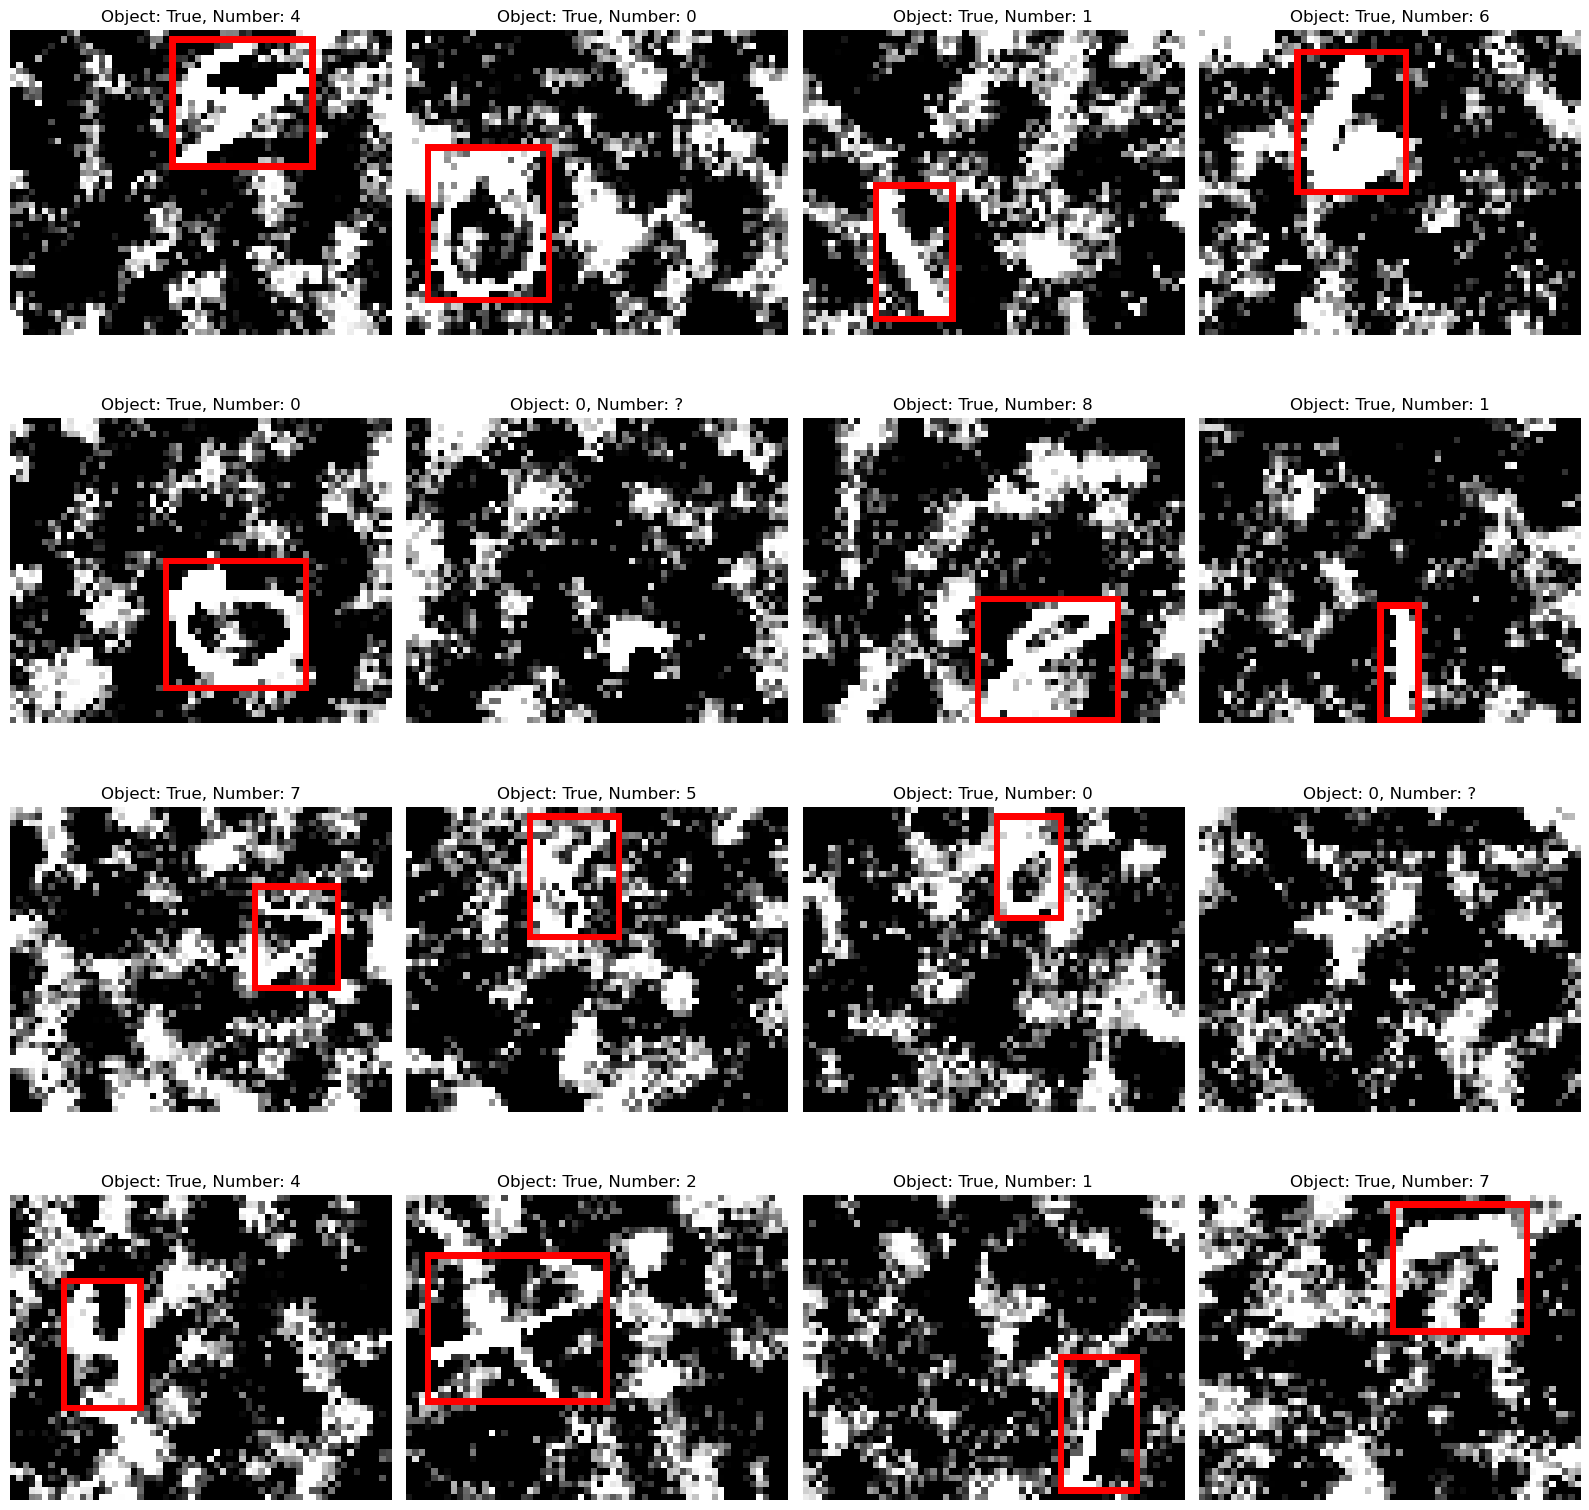

In [78]:
def get_drawn_image(ds, i=0):
    img = ds.tensors[0][i]          # [1,H,W], float [0,1]
    y   = ds.tensors[1][i].float()  # [6]
    H, W = img.shape[-2], img.shape[-1]

    # y[1:5] = (cx, cy, w, h) normalisert
    box = y[1:5].unsqueeze(0)                   # [1,4]
    box_xyxy = box_convert(box, "cxcywh", "xyxy")  # [1,4] normalisert

    # Skaler til pixels
    box_xyxy = box_xyxy * torch.tensor([W, H, W, H], dtype=torch.float32)

    # Gjør bildet klarere for visning 
    img_u8 = (img.clamp(0,1) * 255).to(torch.uint8).repeat(3, 1, 1)

    if int(y[0].item()) == 0:
        return img_u8.permute(1,2,0).numpy(), int(y[0].item()), '?'

    drawn = torchvision.utils.draw_bounding_boxes(img_u8, box_xyxy, colors="red", width=1)
    return drawn.permute(1,2,0).numpy(), bool(y[0].item()), int(y[-1].item())


def show_samples(ds, n=7):
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()  

    for i in range(n):
        img, cls, number = get_drawn_image(ds, i)
        axes[i].imshow(img)
        axes[i].set_title(f"Object: {cls}, Number: {number}")
        axes[i].axis("off")

    # Skjul tomme subplot hvis n ikke fyller gridet
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(norm_train, 16)

# Model definition

In [ ]:
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

num_classes = int(train.tensors[1][:, 5].max().item()) + 1 
print(f"{num_classes} classes")

class Net(nn.Module):
    def __init__(
        self,
        input_channels=1,
        input_size=(48, 60),  
        conv_configs=None,
        fc_hidden_sizes=None,
        num_classes=15,
        pool_size=2,
        dropout=0.0,
    ):
        super(Net, self).__init__()

        if conv_configs is None:
            conv_configs = [(6, 5), (16, 5)]
        if fc_hidden_sizes is None:
            fc_hidden_sizes = [120, 84]

        self.convs = nn.ModuleList()
        self.pool = nn.MaxPool2d(pool_size, pool_size)
        in_ch = input_channels
        for out_ch, k in conv_configs:
            self.convs.append(nn.Conv2d(in_ch, out_ch, k))
            in_ch = out_ch

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, *input_size)
            for conv in self.convs:
                dummy = self.pool(F.relu(conv(dummy)))
            flat_size = dummy.view(1, -1).shape[1]

        print(f"Computed flat size: {flat_size}")

        self.dropout = nn.Dropout(dropout)
        self.fcs = nn.ModuleList()
        in_feat = flat_size
        for hidden in fc_hidden_sizes:
            self.fcs.append(nn.Linear(in_feat, hidden))
            in_feat = hidden
        self.out = nn.Linear(in_feat, num_classes)

    def forward(self, x):
        for conv in self.convs:
            x = self.pool(F.relu(conv(x)))
        x = x.view(x.size(0), -1)
        for fc in self.fcs:
            x = self.dropout(F.relu(fc(x)))
        return self.out(x)

net_original = Net()


net_light = Net(
    conv_configs=[(4, 3), (8, 3)],
    fc_hidden_sizes=[64],
    num_classes=num_classes,
)



net_deep = Net(
    conv_configs=[(32, 3), (64, 3), (128, 3)],
    fc_hidden_sizes=[512, 256],
    dropout=0.5
)


net_wide = Net(
    conv_configs=[(32, 5), (64, 5)],
    fc_hidden_sizes=[1024, 512, 256],
    dropout=0.3
)

Training on device cuda.
10 classes
Computed flat size: 1728
Computed flat size: 1040
Computed flat size: 2560
Computed flat size: 6912


## Localization


In [80]:
def localization_loss(y_pred, y_true, alpha=1.0, beta=1.0, gamma=1.0):
    obj_mask = y_true[:, 0] == 1  # True where an object is present

    # Detection loss (always computed)
    det_loss = nn.BCEWithLogitsLoss()(y_pred[:, 0], y_true[:, 0])

    # Box + class loss ONLY where object is present
    if obj_mask.sum() > 0:  # avoid empty mask
        box_loss = F.mse_loss(
            y_pred[obj_mask, 1:5], 
            y_true[obj_mask, 1:5]
        )
        cls_loss = nn.CrossEntropyLoss()(
            y_pred[obj_mask, 5:], 
            y_true[obj_mask, 5].long()
        )
    else:
        box_loss = torch.tensor(0.0)
        cls_loss = torch.tensor(0.0)

    return alpha * det_loss + beta * box_loss + gamma * cls_loss

### Training

In [ ]:
trainloader = torch.utils.data.DataLoader(train, batch_size=4,
                                          shuffle=True, num_workers=2)

optimizer = optim.SGD(net_original.parameters(), lr=0.001, momentum=0.9)

for epoch in range(6):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = net_original(inputs)
        loss = localization_loss(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')


torch.Size([4, 1, 48, 60])
[1,  2000] loss: 2.634
[1,  4000] loss: 2.594


KeyboardInterrupt: 

In [48]:
outputs.shape

torch.Size([4, 15])

### Predictions

In [49]:
def predict(net, dataloader):
    net.eval()
    all_preds = []
    with torch.no_grad():
        for data in dataloader:
            inputs, _ = data
            outputs = net(inputs)
            all_preds.append(outputs.cpu())
    return torch.cat(all_preds, dim=0)


In [50]:
predictions = predict(net, trainloader)
print(predictions.shape)
print(predictions[:])

torch.Size([59400, 15])
tensor([[ 1.9915, -0.5027,  7.4787,  ...,  0.2350, -0.2267,  0.0636],
        [ 1.9915, -0.5027,  7.4787,  ...,  0.2350, -0.2267,  0.0636],
        [ 1.9915, -0.5027,  7.4787,  ...,  0.2350, -0.2267,  0.0636],
        ...,
        [ 1.9915, -0.5027,  7.4787,  ...,  0.2350, -0.2267,  0.0636],
        [ 1.9915, -0.5027,  7.4786,  ...,  0.2350, -0.2267,  0.0636],
        [ 1.9915, -0.5027,  7.4787,  ...,  0.2350, -0.2267,  0.0636]])


In [51]:
y = train.tensors[1][0].float()
print("y shape:", y.shape)
print("pc:", y[0].item())
print("box part y[1:5]:", y[1:5])
print("rest:", y[5:10])

y shape: torch.Size([6])
pc: 1.0
box part y[1:5]: tensor([0.6000, 0.2292, 0.3667, 0.4167])
rest: tensor([4.])


In [52]:
print(predictions[0])

tensor([ 1.9915e+00, -5.0274e-01,  7.4787e+00,  1.4555e+00, -6.7192e+00,
        -5.7559e-02,  2.6248e-01, -1.5089e-02,  5.9120e-03, -2.3233e-01,
        -4.5049e-01,  1.0681e-01,  2.3499e-01, -2.2666e-01,  6.3587e-02])


In [53]:
print(train.tensors[1][0])

tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167, 4.0000])


### Model selection and evaluation

In [54]:
def intersection(bb1, bb2):
    box1_cxcywh=bb1[1:5]
    box2_cxcywh=bb2[1:5]
    box1 = box_convert(box1_cxcywh.unsqueeze(0), "cxcywh", "xyxy")
    box2 = box_convert(box2_cxcywh.unsqueeze(0), "cxcywh", "xyxy")

    x_min = torch.max(box1[:, 0], box2[:, 0])
    y_min = torch.max(box1[:, 1], box2[:, 1])
    x_max = torch.min(box1[:, 2], box2[:, 2])
    y_max = torch.min(box1[:, 3], box2[:, 3])

    w = (x_max - x_min).clamp(min=0)
    h = (y_max - y_min).clamp(min=0)

    return (w * h).squeeze(0)  
   
def IoU(bb1, bb2):
    intersect = intersection(bb1, bb2)
    area1 = bb1[3] * bb1[4]
    area2 = bb2[3] * bb2[4]
    unionArea = area1 + area2 - intersect
    return intersect / (unionArea + 1e-8)
   
def compute_IoU_localization(model, loader, preprocessor):
    total_iou = 0.0
    total=0

    for images, labels in loader:
        model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            for out, lab in zip(outputs, labels):
                if lab[0].item() != 1:
                    continue  # teller ikke med i IoU hvis det ikke er et objekt
                iou_score = IoU(out, lab)
                total_iou += iou_score.item()
                total += 1
    return total_iou / total if total > 0 else 0.0

def compute_accuracy_localization(model, loader, preprocessor, pc_has_sigmoid=False):
    model.eval()
    if device is None:
        device = next(model.parameters()).device
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)  
            try:
                x = preprocessor(images)
            except TypeError:
                x = preprocessor(images, labels)

            outputs = model(x)  
            for out, lab in zip(outputs, labels):

                # Bare bilder med objekt teller
                if lab[0].item() != 1:
                    continue

                total += 1

                # Objekt deteksjon 
                pc_pred = out[0]

                if pc_has_sigmoid:
                    object_detected = pc_pred > 0.5
                else:
                    object_detected = torch.sigmoid(pc_pred) > 0.5

                # --- Klassifikasjon ---
                pred_label = torch.argmax(out[5:])
                true_label = torch.argmax(lab[5:])

                if object_detected and pred_label == true_label:
                    correct += 1

    return correct / total if total > 0 else 0.0
    

In [55]:
import torch
import torchvision
from torchvision.ops import box_convert

def _sanitize_xyxy(boxes_xyxy, W, H):
    x1, y1, x2, y2 = boxes_xyxy.unbind(dim=1)
    xmin = torch.min(x1, x2)
    xmax = torch.max(x1, x2)
    ymin = torch.min(y1, y2)
    ymax = torch.max(y1, y2)

    xmin = xmin.clamp(0, W - 1)
    xmax = xmax.clamp(0, W - 1)
    ymin = ymin.clamp(0, H - 1)
    ymax = ymax.clamp(0, H - 1)

    # unngå 0/negativ bredde/høyde
    eps = 1.0
    xmax = torch.max(xmax, xmin + eps)
    ymax = torch.max(ymax, ymin + eps)

    return torch.stack([xmin, ymin, xmax, ymax], dim=1)

def pred_vs_actual(dataset, pred, i, pc_has_sigmoid=False):
    img = dataset.tensors[0][i]          # [1,H,W]
    y   = dataset.tensors[1][i].float()  # [6] = [pc,cx,cy,w,h,label]
    H, W = img.shape[-2], img.shape[-1]

    pc_true = int(y[0].item())
    true_label = int(y[5].item()) if pc_true == 1 else None

    # GT boks (cxcywh normalisert)
    gt_cxcywh = y[1:5].unsqueeze(0)

    # Pred boks (cxcywh), gjør w/h positive for tegning
    pr_cxcywh = pred[i][1:5].clone()
    pr_cxcywh[2:] = pr_cxcywh[2:].abs().clamp(min=1e-6)
    pr_cxcywh = pr_cxcywh.unsqueeze(0)

    # til xyxy (normalisert)
    gt_xyxy = box_convert(gt_cxcywh, "cxcywh", "xyxy")
    pr_xyxy = box_convert(pr_cxcywh, "cxcywh", "xyxy")

    # til pixels
    scale = torch.tensor([W, H, W, H], dtype=torch.float32).unsqueeze(0)
    gt_xyxy = gt_xyxy * scale
    pr_xyxy = pr_xyxy * scale

    # sanitize
    gt_xyxy = _sanitize_xyxy(gt_xyxy, W, H).to(torch.int64)
    pr_xyxy = _sanitize_xyxy(pr_xyxy, W, H).to(torch.int64)

    # bilde for drawing
    img_u8 = (img.clamp(0,1) * 255).to(torch.uint8).repeat(3,1,1)

    # pred label fra logits
    pred_label = int(torch.argmax(pred[i][5:]).item())

    # hvis ingen objekt i GT: bare returner bilde
    if pc_true == 0:
        return img_u8.permute(1,2,0).numpy(), pc_true, pred_label, true_label

    boxes = torch.cat([gt_xyxy, pr_xyxy], dim=0)
    colors = ["green", "red"]
    drawn = torchvision.utils.draw_bounding_boxes(img_u8, boxes, colors=colors, width=2)

    return drawn.permute(1,2,0).numpy(), pc_true, pred_label, true_label

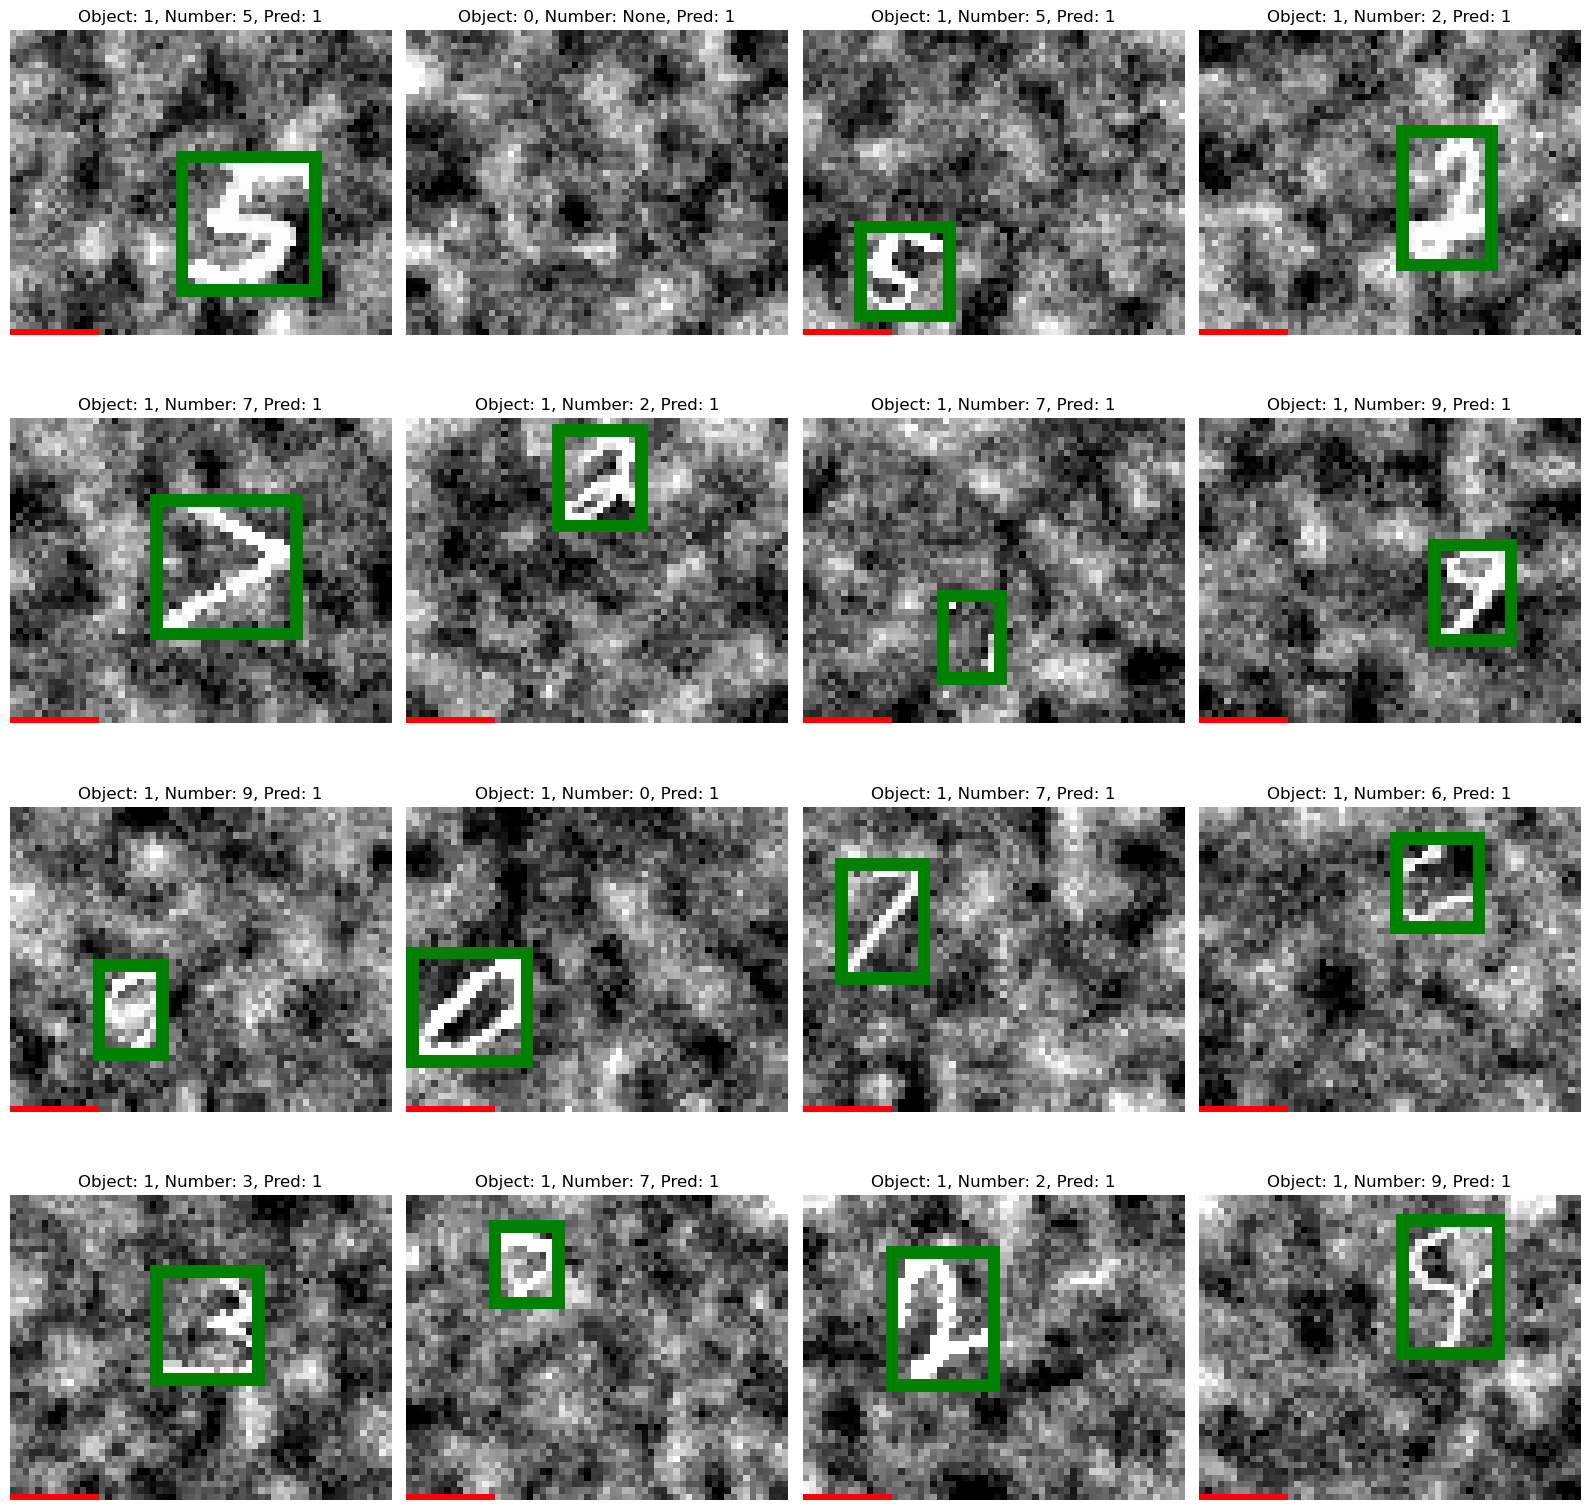

In [56]:
def show_samples(model, ds, preprocessor, n=7, device="cpu"):
    model.eval()

    images = ds.tensors[0][:n].to(device)

    with torch.no_grad():
        try:
            x = preprocessor(images)
        except TypeError:
            x = preprocessor(images, None)

        preds = model(x).cpu()

    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    for i in range(n):
        img, pc, pred_label, true_label = pred_vs_actual(ds, preds, i)

        axes[i].imshow(img)
        axes[i].set_title(f"Object: {pc}, Number: {true_label}, Pred: {pred_label}")
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(net, val, lambda x: x.to(device), n=16, device=device)